# Estimation & Hypothesis Testing

## Imports & Load Clean Data 

In [21]:
import pandas as pd                                       
import numpy as np 
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns  

df = pd.read_csv("../data/cleaned/saas_sales_clean.csv")                               
df.shape

(9994, 22)

## Act 1: The Protagonist — Estimating the AWS SaaS Customer
  Based on our sample of ~10,000 transactions, we estimate the characteristics of the
  overall AWS SaaS customer population using 95% confidence intervals.

In [22]:
# Calculate 95% confidence intervals for key metrics                                   
metrics = ["Sales", "Profit", "Profit Margin", "Discount"]
                                                                                         
for metric in metrics:
    data = df[metric].dropna()       # don't need that                                                  
    mean = data.mean()               # mean works on axes so i don't need a loop, go with apply instead                   
    ci = stats.t.interval(0.95, len(data)-1, loc=mean, scale=stats.sem(data))
    print(f"{metric}: Mean = {mean:.2f}, 95% CI = [{ci[0]:.2f}, {ci[1]:.2f}]")

# no for loops at all, always do apply, or map
                                                                                         

Sales: Mean = 229.86, 95% CI = [217.64, 242.08]
Profit: Mean = 28.66, 95% CI = [24.06, 33.25]
Profit Margin: Mean = 12.03, 95% CI = [11.12, 12.95]
Discount: Mean = 0.16, 95% CI = [0.15, 0.16]


```
Haarklein erklärt:
- stats.t.interval() → Konfidenzintervall mit der t-Verteilung (t-distribution)        
- 0.95 → 95% Konfidenzniveau — "Wenn wir 100 Samples ziehen, liegt der wahre Wert in 95 davon in diesem Intervall"                                                            
- len(data)-1 → Freiheitsgrade (degrees of freedom) = n - 1                            
- loc=mean → Zentrum = unser Sample-Mittelwert             
- stats.sem(data) → Standard Error of the Mean = std / √n — je größer n, desto kleiner der Fehler
```

### Confidence Interval Visualization

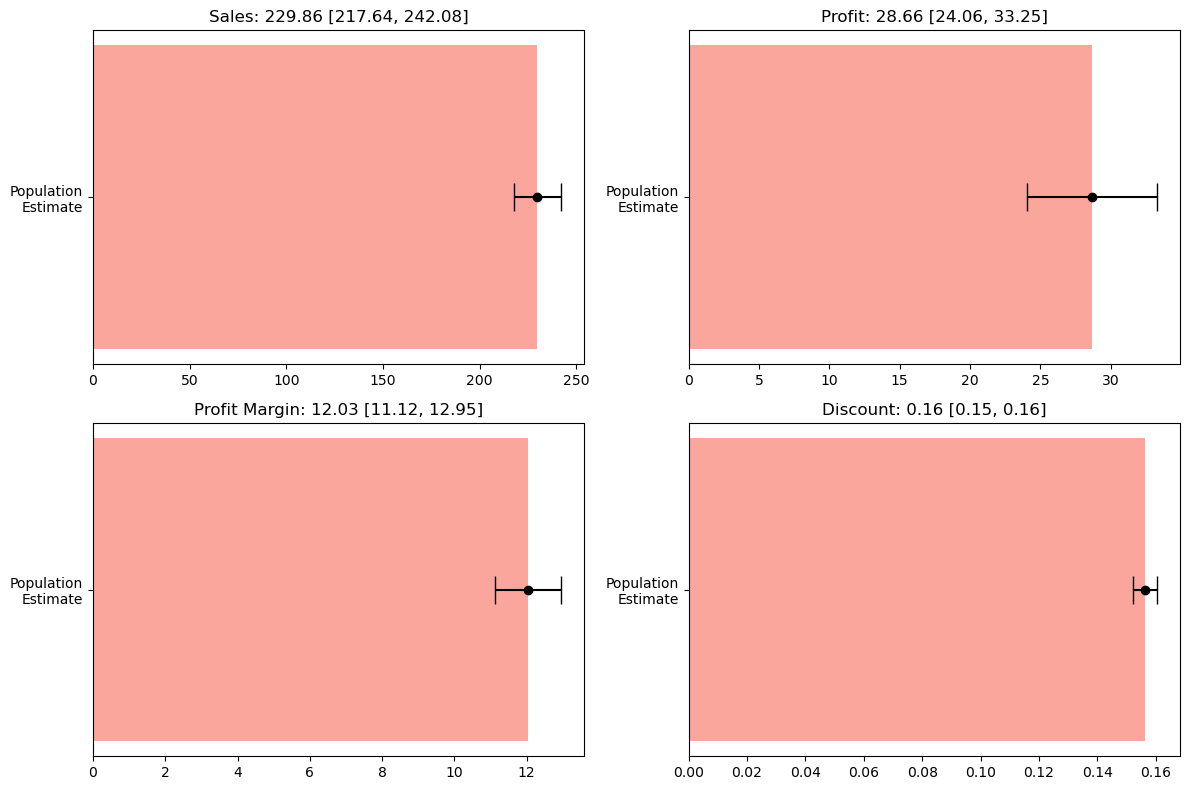

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))                                        
axes = axes.flatten()       

# again mean works on axes so need for enumerate or for loop
# just extract subset of columns I wanna use
                                                                                         
for i, metric in enumerate(metrics):                      
    data = df[metric].dropna()      
    mean = data.mean()        
    ci = stats.t.interval(0.95, len(data)-1, loc=mean, scale=stats.sem(data))
                                                                                         
    axes[i].barh(["Population\nEstimate"], [mean], color="salmon", alpha=0.7)
    axes[i].errorbar(mean, 0, xerr=[[mean - ci[0]], [ci[1] - mean]], fmt="o", color="black", capsize=10)                                                   
    axes[i].set_title(f"{metric}: {mean:.2f} [{ci[0]:.2f}, {ci[1]:.2f}]")              
                                                                           
plt.tight_layout()                                                                     
plt.savefig("../figures/estimation_ci.png")
plt.show() 

```
Wie du den Plot liest:
  - Balken = Mittelwert aus unserem Sample                                               
  - Schwarze Linie mit Kappen = 95% Confidence Interval
  - Je kürzer die Linie, desto präziser unsere Schätzung                                 
  - Bei n=10,000 werden die CIs sehr eng sein — unser Sample ist groß genug
```

**Was wir jetzt über den "typischen AWS SaaS Kunden" sagen können:**                       
   
  "Wir schätzen mit 95% Sicherheit, dass der durchschnittliche AWS SaaS Kunde pro      
  Transaktion zwischen $217 und $242 ausgibt, dabei einen Profit von $24–$33 generiert, 
  mit einer Marge von 11–13% und einem Rabatt von ca. 15–16%."                           
                                                                                         
  Was fällt auf:
  - Sales CI ist relativ breit ($217–$242, Spanne ~$25) — wegen der hohen Skewness und
  Outliers                                                                               
  - Discount CI ist extrem eng (0.15–0.16) — weil Discounts in festen Stufen vergeben
  werden, wenig Varianz                                                                  
  - Profit Margin CI (11–13%) — für SaaS eher niedrig, typisch wären 60-80%. Das zeigt   
  wie stark die Rabatte reinhauen                                                     
                                                                                         
                 
                                                                                         
  

### Estimation Summary                                    
                                                                                         
  | Metric | Population Estimate | 95% CI |                 
  |---|---|---|
  | Sales per Transaction | $229.86 | [$217.64, $242.08] |
  | Profit per Transaction | $28.66 | [$24.06, $33.25] |                                 
  | Profit Margin | 12.03% | [11.12%, 12.95%] |
  | Discount Rate | 16% | [15%, 16%] |  

                                                            

We estimate with 95% confidence that the average AWS SaaS transaction generates      
between $217 and $242 in sales, with a profit of $24–$33 and a margin of 11–13%. The
average discount rate is tightly estimated around 15–16%. 

## Act 2: The Hero Stories 

### BQ1: Do AWS SaaS customers in wealthier countries generate higher profit?          
  - H₀: GDP per capita has no predictive power for profit per transaction                
  - H₁: GDP per capita is a significant predictor of profit per transaction              
  - Test: Linear Regression

In [24]:
# Aggregate by country — average profit and GDP per capita                             
df_country = df.groupby("Country").agg(                   
                    Avg_Profit=("Profit", "mean"),                                                     
                    GDP_per_Capita=("GDP_per_Capita", "first"),                                        
                    Transactions=("Profit", "count")                                                   
                )\
                .dropna()\
                .reset_index()                                                               
                                                            
df_country.shape 

(47, 4)

```
Warum aggregieren? Jedes Land hat einen GDP-Wert, aber viele Transaktionen. Wenn wir
nicht aggregieren, würden Länder mit vielen Transaktionen (z.B. USA) das Ergebnis      
dominieren. Mit groupby("Country") bekommen wir einen Datenpunkt pro Land — fairer
Vergleich.
```

In [40]:
# Linear Regression
slope, intercept, r_value, p_value, std_err = stats.linregress(
    df_country["GDP_per_Capita"], df_country["Avg_Profit"]     
)                                                                                      
                                                                                         
print(f"Slope: {slope:.6f}")                                                           
print(f"R-squared: {r_value**2:.4f}")                                                  
print(f"P-value: {p_value:.4f}")


Slope: 0.000121
R-squared: 0.0053
P-value: 0.6264


```
Haarklein erklärt:                                                                     
- stats.linregress() → berechnet die Regressionsgerade y = slope * x + intercept
- Slope (Steigung): Um wie viel Dollar steigt der Profit, wenn GDP per Capita um $1    
steigt                                                                             
- R-squared (Bestimmtheitsmaß): Wie viel % der Profit-Varianz wird durch GDP erklärt. 0
= gar nichts, 1 = alles                                                               
- P-value: Wahrscheinlichkeit, dieses Ergebnis zu sehen wenn H₀ wahr wäre. Unter 0.05 =
signifikant = H₀ ablehnen 
```

Ok, klares Ergebnis:                                                                   
                                                                                         
  - P-value = 0.63 → weit über 0.05 → H₀ NOT rejected                                    
  - R² = 0.005 → GDP erklärt nur 0.5% der Profit-Varianz — praktisch nichts              
  - Slope = 0.000121 → selbst wenn GDP um $10,000 steigt, steigt der Profit nur um $1.21 
                                                                                         
  Fazit: GDP per Capita hat keinen signifikanten Einfluss auf den Profit pro Transaktion.
                                                                                         
  Das ist übrigens kein schlechtes Ergebnis! In der Präsentation sagst du:               
                                                            
"We expected wealthier countries to generate more profit, but the data tells a different story — GDP per capita does not predict SaaS profitability. This suggests AWS SaaS pricing and profit are driven by internal factors (like discounts and segment) rather than external economic conditions." 

#### **BQ1 Note on H₀ alignment**
  `stats.linregress()` internally tests H₀: "The slope equals zero" (i.e., no linear     
  relationship between x and y). This aligns with our hypothesis H₀: "GDP per capita has 
  no predictive power for profit." A high p-value (0.63) means we cannot reject the
  possibility that the slope is due to random chance — confirming no significant         
  relationship.                                             

  **Remark for future projects:** Always verify that the built-in H₀ of the statistical  
  function matches your own H₀. Check the documentation — different functions test
  different null hypotheses. If they don't align, you may need a different function or   
  manual calculation.    

#### BQ1 Visualization

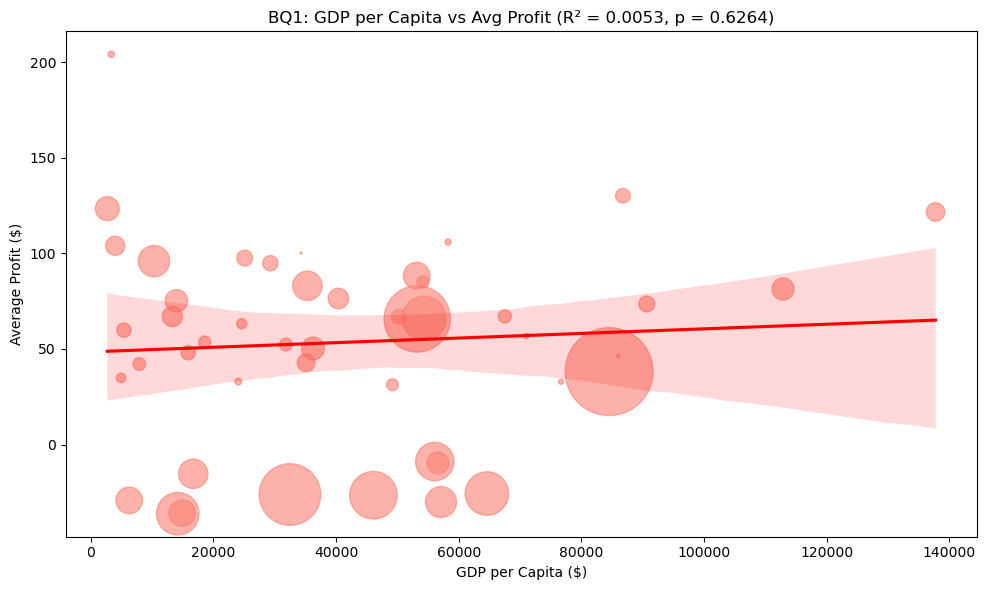

In [26]:
fig, ax = plt.subplots(figsize=(10, 6))                                                
                                         
# Scatter plot with regression line                                                    
sns.regplot(data=df_country, x="GDP_per_Capita", y="Avg_Profit",
            scatter_kws={"s": df_country["Transactions"]*2, "alpha": 0.6},             
            line_kws={"color": "red"}, color="salmon", ax=ax)             
                                                                                         
ax.set_xlabel("GDP per Capita ($)")                                                    
ax.set_ylabel("Average Profit ($)")                                                    
ax.set_title(f"BQ1: GDP per Capita vs Avg Profit (R² = {r_value**2:.4f}, p = {p_value:.4f})")                                                             
                                                                                         
plt.tight_layout()
plt.savefig("../figures/bq1_gdp_profit.png")                                           
plt.show()     

```
Wie du den Plot liest:                                                                 
  - Jeder Punkt = ein Land
  - Größe des Punkts = Anzahl Transaktionen (größer = mehr Transaktionen)                
  - Rote Linie = Regressionsgerade — zeigt den Trend                     
  - Schattierter Bereich um die Linie = 95% Confidence Interval der Regression           
  - Steigt die Linie nach rechts oben → positive Beziehung (reichere Länder = mehr     Profit)                                                                                
  - Punkte weit von der Linie = Ausreißer, die nicht ins Muster passen 
  ```

#### BQ1 Result

  | Metric | Value | Interpretation |                                                    
  |---|---|---|
  | Slope | 0.000121 | +$1.21 profit per $10,000 GDP increase |                          
  | R² | 0.0053 | GDP explains only 0.5% of profit variance |                            
  | P-value | 0.6264 | Not significant (> 0.05) |
                                                                                         
  **Result: H₀ not rejected.** GDP per capita has no significant predictive power for    
  profit per transaction. SaaS profitability appears to be driven by internal factors    
  (discounts, segment) rather than a country's wealth.

### BQ2: Is AWS SaaS adoption higher in countries with better internet access?        
  - H₀: There is no relationship between internet penetration and number of transactions 
  - H₁: Countries with higher internet penetration have significantly more transactions  
  - Test: Pearson Correlation 

In [ ]:
# Aggregate by country — transaction count and internet penetration                    
df_country2 = df.groupby("Country").agg(                                               
                    Transactions=("Profit", "count"),                     
                    Internet_Penetration=("Internet_Penetration", "first")                             
                )\
                .dropna()\
                .reset_index()                                  
                                                                                         
# Two-tailed (original)                                                                
r, p_two = stats.pearsonr(df_country2["Internet_Penetration"],
df_country2["Transactions"])                                                           
                                                                                         
# One-tailed (our H1 is directional: MORE transactions)                                
p_one = p_two / 2                                                                      
                                                            
print(f"Pearson r: {r:.4f}")                                                           
print(f"P-value (two-tailed): {p_two:.4f}")               
print(f"P-value (one-tailed): {p_one:.4f}")

# Update result

Pearson r: 0.0749
P-value (two-tailed): 0.6169
P-value (one-tailed): 0.3085


Unterschied erklärt:
  - Two-tailed: Testet "ist r irgendwie verschieden von 0?" (positiv oder negativ)       
  - One-tailed: Testet nur "ist r positiv?" — weil unsere H₁ eine Richtung hat ("more    
  transactions")                                                                     
  - P-value halbiert sich → aber bei 0.62 wird auch 0.31 nicht signifikant 

```
Haarklein erklärt:                                                                     
  - stats.pearsonr() → berechnet den Pearson-Korrelationskoeffizienten und den P-value
  - r (Korrelation): -1 bis +1. Positiv = je mehr Internet, desto mehr Transaktionen     
  - P-value: Unter 0.05 = signifikant
```

#### BQ2 Visualization

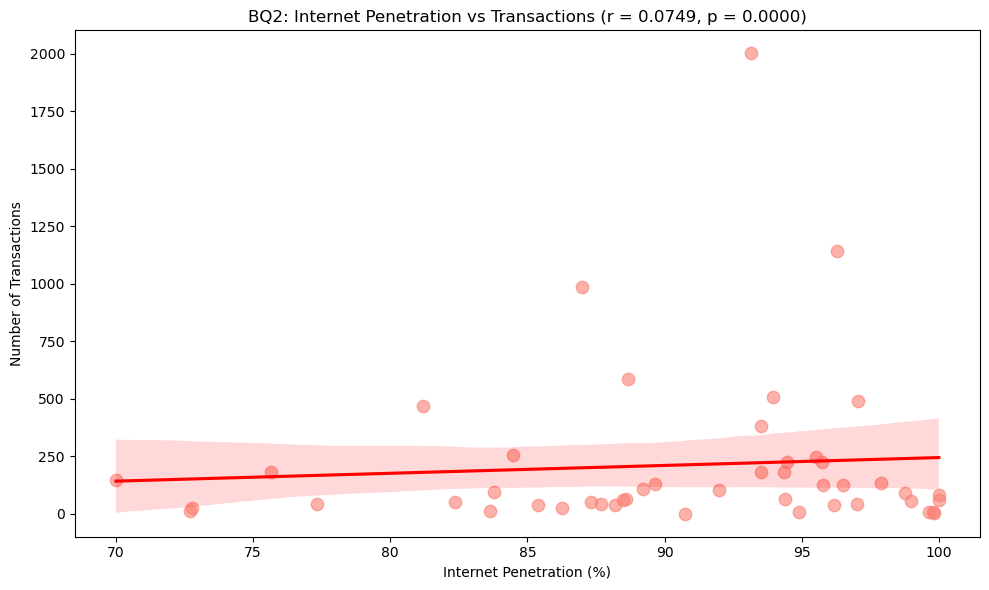

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))                   
                                         
sns.regplot(data=df_country2, x="Internet_Penetration", y="Transactions",
            scatter_kws={"s": 80, "alpha": 0.6},                                       
            line_kws={"color": "red"}, color="salmon", ax=ax)
                                                                                         
ax.set_xlabel("Internet Penetration (%)")                                              
ax.set_ylabel("Number of Transactions")  
ax.set_title(f"BQ2: Internet Penetration vs Transactions (r = {r:.4f}, p = {p_value:.4f})")                                          
                                                                                         
plt.tight_layout()
plt.savefig("../figures/bq2_internet_transactions.png")                                
plt.show() 


#### BQ2 Outlier Analysis — Transactions outside 95% CI

In [ ]:
# Calculate 95% CI for transactions per country                                        
mean_t = df_country2["Transactions"].mean()    
ci = stats.t.interval(0.95, len(df_country2)-1, loc=mean_t,                            
scale=stats.sem(df_country2["Transactions"]))                                          
                                                                                         
print(f"Mean transactions per country: {mean_t:.2f}")                                  
print(f"95% CI: [{ci[0]:.2f}, {ci[1]:.2f}]")                                           
                                                            
# Countries outside the 95% CI                                                         
outliers = df_country2[(df_country2["Transactions"] < ci[0]) |
(df_country2["Transactions"] > ci[1])]                                                 
print(f"\nCountries outside 95% CI ({len(outliers)}):")                                
print(outliers.sort_values("Transactions", ascending=False).to_string(index=False))

# add to result 

Mean transactions per country: 212.19
95% CI: [107.31, 317.07]

Countries outside 95% CI (34):
             Country  Transactions  Internet_Penetration
       United States          2001               93.1444
      United Kingdom          1141               96.2988
               Japan           985               86.9815
              France           587               88.6538
              Canada           506               93.9564
           Australia           492               97.0631
              Mexico           469               81.1832
             Germany           383               93.5000
               China           105               92.0000
         Philippines            96               83.7661
          Luxembourg            89               98.7606
        Saudi Arabia            82              100.0000
           Singapore            66               94.3776
              Poland            66               88.5850
            Portugal            61               8

#### BQ2 Outlier Insight                                                               
                                                                                         
  | Country | Transactions | Internet Penetration |                                      
  |---|---|---|
  | United States | 2,001 | 93.14% |
  | United Kingdom | 1,141 | 96.30% |                                                    
  | Japan | 985 | 86.98% |
  | France | 587 | 88.65% |                                                              
  | Canada | 506 | 93.96% |                                                              
  | Australia | 492 | 97.06% |
  | Mexico | 469 | 81.18% |                                                              
  | Germany | 383 | 93.50% |             
                                                                                         
  These 8 countries all exceed the 95% CI for transaction count. They are major economies
   and key AWS markets — their high transaction volume reflects market size and AWS      
  presence, not internet penetration. For example, Australia (97%) has fewer transactions
   than Mexico (81%) despite much higher internet access.

#### BQ2 Result                                                                        
                                                            
  | Metric | Value | Interpretation |
  |---|---|---|
  | Pearson r | 0.0749 | Almost no correlation |
  | P-value | 0.6169 | Not significant (> 0.05) |
                                                                                         
  **Result: H₀ not rejected.** Internet penetration does not predict the number of SaaS  
  transactions per country. Combined with BQ1, this suggests that AWS SaaS performance is
   independent of external economic factors — the business is driven by internal factors 
  like pricing strategy and customer segment.

### BQ3: Do AWS SaaS discount strategies differ across regions?                       
  - H₀: There is no difference in discount rates between EMEA and AMER                   
  - H₁: Discount rates differ significantly between EMEA and AMER                        
  - Test: Independent Samples t-Test  

In [29]:
# Split into two samples                                                             
emea_discount = df[df["Region"] == "EMEA"]["Discount"]                                 
amer_discount = df[df["Region"] == "AMER"]["Discount"]    
                                                                                         
# Independent samples t-test
t_stat, p_value = stats.ttest_ind(emea_discount, amer_discount)                        
                                                                 
print(f"EMEA mean discount: {emea_discount.mean():.4f}")                               
print(f"AMER mean discount: {amer_discount.mean():.4f}")                               
print(f"T-statistic: {t_stat:.4f}")                     
print(f"P-value: {p_value:.4f}")

EMEA mean discount: 0.1414
AMER mean discount: 0.1094
T-statistic: 8.0876
P-value: 0.0000


```
Haarklein erklärt:                                                                     
  - stats.ttest_ind() → Independent Samples t-Test — vergleicht die Mittelwerte zweier
  unabhängiger Gruppen                                                                   
  - T-statistic: Wie weit die Mittelwerte auseinander liegen, gemessen in
  Standardfehlern. Je größer (positiv oder negativ), desto deutlicher der Unterschied    
  - P-value: Unter 0.05 = der Unterschied ist statistisch signifikant, nicht zufällig    
  - Wir vergleichen nur EMEA vs AMER — APJ lassen wir raus, weil die BQ so formuliert
  ist. APJ haben wir schon in der EDA als Ausreißer identifiziert
```

#### BQ3 Visualization

/var/folders/gn/zvx5kxqj5ng9ng0cg5f15yk80000gn/T/ipykernel_98806/2146927848.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[df["Region"].isin(["EMEA", "AMER"])],


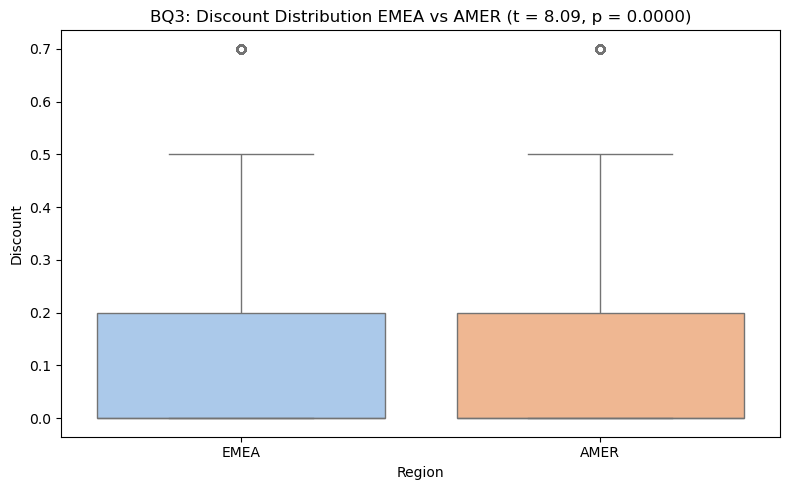

In [30]:
fig, ax = plt.subplots(figsize=(8, 5))
                                        
sns.boxplot(data=df[df["Region"].isin(["EMEA", "AMER"])],                              
            x="Region", y="Discount", palette="pastel", ax=ax)                         
                                                                                         
ax.set_title(f"BQ3: Discount Distribution EMEA vs AMER (t = {t_stat:.2f}, p = {p_value:.4f})")                                                                       
                  
plt.tight_layout()                                                                     
plt.savefig("../figures/bq3_discount_regions.png")        
plt.show()

```
Wie du den Plot liest:
  - Vergleiche die Höhe der Boxen und den Median (Linie in der Mitte)                    
  - Wenn die Boxen sich kaum überlappen → wahrscheinlich signifikanter Unterschied       
  - Wenn sie stark überlappen → Unterschied eher zufällig
  ```

#### BQ3 Result                                           
                                                                                         
  | Metric | Value | Interpretation |
  |---|---|---|                                                                          
  | EMEA mean discount | 14.14% | Higher discount strategy |
  | AMER mean discount | 10.94% | Lower discount strategy |
  | T-statistic | 8.0876 | Large difference between groups |                             
  | P-value | 0.0000 | Highly significant (< 0.05) |
                                                                                         
  **Result: H₀ rejected.** EMEA applies significantly higher discounts than AMER.        
  Combined with the EDA finding that APJ discounts even more aggressively (27%), this    
  reveals a clear pattern: discount strategy varies substantially across regions, with   
  potential impact on profitability. 

### BQ4: Does the customer segment affect AWS SaaS profitability?                     
  - H₀: There is no difference in profit across customer segments (SMB / Strategic /     
  Enterprise)                                                                            
  - H₁: Profit differs significantly across customer segments                            
  - Test: One-Way ANOVA   

In [ ]:
# Split into three samples                                                             
smb = df[df["Segment"] == "SMB"]["Profit"]                
strategic = df[df["Segment"] == "Strategic"]["Profit"]                                 
enterprise = df[df["Segment"] == "Enterprise"]["Profit"]
                                                                                         
# One-Way ANOVA                                                                        
f_stat, p_value = stats.f_oneway(smb, strategic, enterprise)

# Paired ANOVA

                                                                                         
print(f"SMB mean profit: {smb.mean():.2f}")               
print(f"Strategic mean profit: {strategic.mean():.2f}")
print(f"Enterprise mean profit: {enterprise.mean():.2f}")
print(f"F-statistic: {f_stat:.4f}")                                                    
print(f"P-value: {p_value:.4f}")

# Remove outliers and then violin plot

SMB mean profit: 25.84
Strategic mean profit: 30.46
Enterprise mean profit: 33.82
F-statistic: 0.8981
P-value: 0.4074


```
Haarklein erklärt:                                                                     
  - stats.f_oneway() → One-Way ANOVA — vergleicht Mittelwerte von 3+ Gruppen gleichzeitig
   (t-Test kann nur 2)                                                                   
  - F-statistic: Verhältnis von Varianz zwischen den Gruppen zu Varianz innerhalb der
  Gruppen. Je größer F, desto deutlicher der Unterschied                                 
  - P-value: Unter 0.05 = mindestens eine Gruppe unterscheidet sich signifikant          
  - Wichtig: ANOVA sagt dir ob ein Unterschied existiert, aber nicht welche Gruppen sich
  unterscheiden — dafür bräuchte man einen Post-hoc Test (z.B. Tukey), aber das ist für 5
   Minuten Präsentation zu viel 
   ```

#### BQ4 Note on Paired vs Independent ANOVA                                           
A paired (repeated measures) ANOVA requires the **same subjects** to be measured across all groups — e.g., the same customer appearing in SMB, Strategic, and Enterprise. In our dataset, each transaction belongs to **exactly one** segment. The groups are independent, not paired. Therefore, an independent (one-way) ANOVA is the correct test.
                                                                                       

#### BQ4 Visualization

/var/folders/gn/zvx5kxqj5ng9ng0cg5f15yk80000gn/T/ipykernel_98806/1686283561.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Segment", y="Profit", palette="pastel",


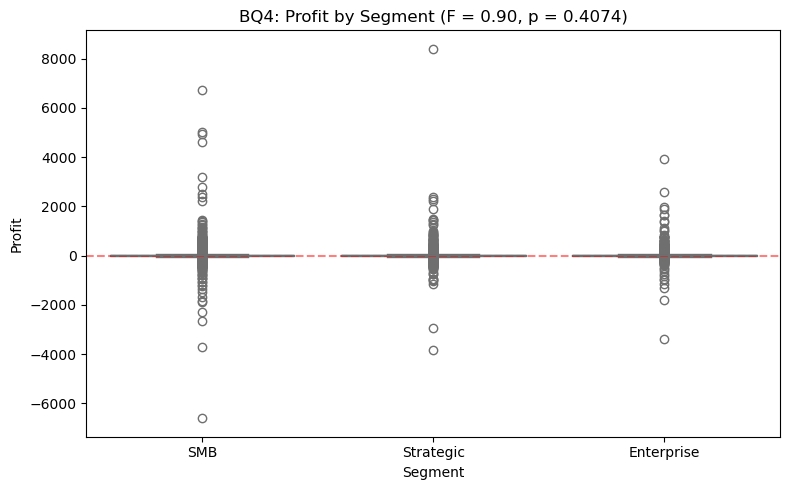

In [32]:
fig, ax = plt.subplots(figsize=(8, 5))
                                        
sns.boxplot(data=df, x="Segment", y="Profit", palette="pastel",                        
            order=["SMB", "Strategic", "Enterprise"], ax=ax)   
ax.axhline(y=0, color="red", linestyle="--", alpha=0.5)                                
ax.set_title(f"BQ4: Profit by Segment (F = {f_stat:.2f}, p = {p_value:.4f})")
                                                                                         
plt.tight_layout()                                                                     
plt.savefig("../figures/bq4_profit_segment.png")                                       
plt.show()

```
Wie du den Plot liest:
  - Vergleiche die Mediane (Linien in den Boxen) — steigen sie von SMB → Enterprise?     
  - Rote Linie bei 0 → alles darunter ist Verlust                                        
  - Schau wie weit die Boxen unter die rote Linie gehen — welches Segment hat die meisten
   Verluste?
   ```

#### BQ4 Re-test: ANOVA with Clipped Outliers

In [41]:
# Clip outliers at 5th and 95th percentile
lower = df["Profit"].quantile(0.05)                                                    
upper = df["Profit"].quantile(0.95)                                                    
df_clipped = df[(df["Profit"] >= lower) & (df["Profit"] <= upper)]
                                                                                         
print(f"Clipping range: [{lower:.2f}, {upper:.2f}]")                                   
print(f"Rows before: {len(df)}, after: {len(df_clipped)}")                             
                                                                                         
# Re-run ANOVA on clipped data                                                         
smb_c = df_clipped[df_clipped["Segment"] == "SMB"]["Profit"]                           
strategic_c = df_clipped[df_clipped["Segment"] == "Strategic"]["Profit"]
enterprise_c = df_clipped[df_clipped["Segment"] == "Enterprise"]["Profit"]             
                                                                            
f_stat_c, p_value_c = stats.f_oneway(smb_c, strategic_c, enterprise_c)                 
                                                                                         
print(f"\nSMB mean: {smb_c.mean():.2f}")
print(f"Strategic mean: {strategic_c.mean():.2f}")                                     
print(f"Enterprise mean: {enterprise_c.mean():.2f}")      
print(f"F-statistic: {f_stat_c:.4f}")                                                  
print(f"P-value: {p_value_c:.4f}") 

Clipping range: [-53.03, 168.47]
Rows before: 9994, after: 8995

SMB mean: 18.69
Strategic mean: 19.29
Enterprise mean: 20.41
F-statistic: 1.5671
P-value: 0.2087


```
Warum clippen:
  - Die Outliers erzeugen riesige Varianz innerhalb der Gruppen → der kleine Unterschied 
  zwischen den Gruppen geht unter                                                        
  - Beim 5. und 95. Perzentil abschneiden entfernt extreme Werte auf beiden Seiten
  - Wenn der P-value danach unter 0.05 fällt, wissen wir: der Unterschied war da, nur von
   Outliers verdeckt
   ```

#### BQ4 Violin Plot (Clipped)

/var/folders/gn/zvx5kxqj5ng9ng0cg5f15yk80000gn/T/ipykernel_98806/126171619.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="Segment", y="Profit", palette="pastel",
/var/folders/gn/zvx5kxqj5ng9ng0cg5f15yk80000gn/T/ipykernel_98806/126171619.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_clipped, x="Segment", y="Profit", palette="pastel",


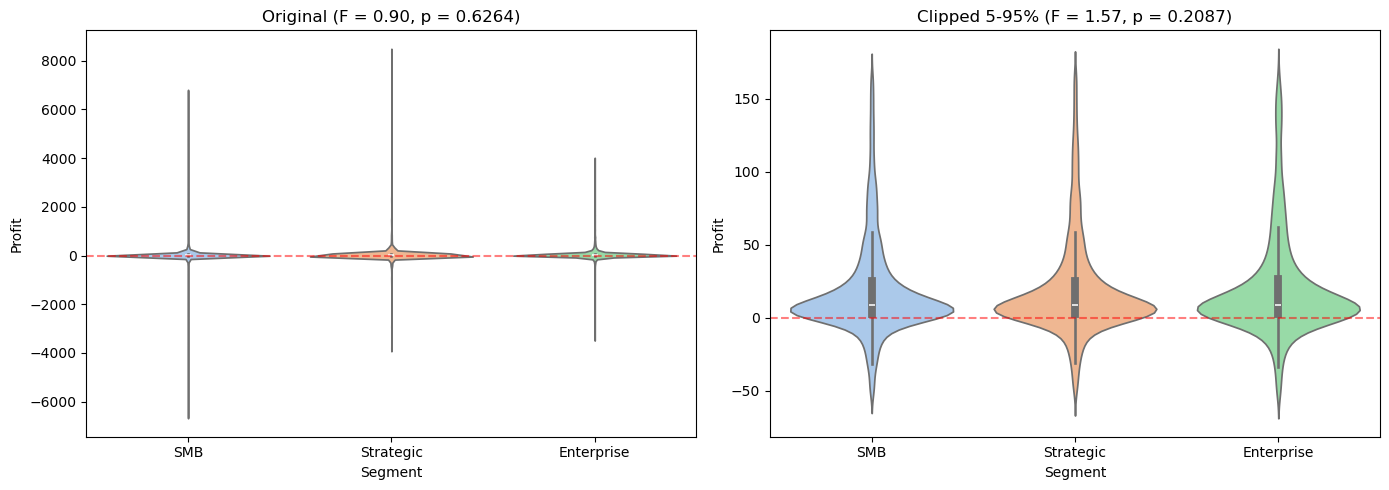

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))                                        
                                                 
# Left: original data                                                                  
sns.violinplot(data=df, x="Segment", y="Profit", palette="pastel",
                order=["SMB", "Strategic", "Enterprise"], ax=axes[0])                   
axes[0].axhline(y=0, color="red", linestyle="--", alpha=0.5)                           
axes[0].set_title(f"Original (F = {f_stat:.2f}, p = {p_value:.4f})")
                                                                                         
# Right: clipped data                                                                  
sns.violinplot(data=df_clipped, x="Segment", y="Profit", palette="pastel",             
                order=["SMB", "Strategic", "Enterprise"], ax=axes[1])                   
axes[1].axhline(y=0, color="red", linestyle="--", alpha=0.5)        
axes[1].set_title(f"Clipped 5-95% (F = {f_stat_c:.2f}, p = {p_value_c:.4f})")          
                                                                               
plt.tight_layout()                                                                     
plt.savefig("../figures/bq4_violin_comparison.png")                                    
plt.show()  

```
Wie du den Violin Plot liest:                             
  - Wie ein Boxplot, aber die Form zeigt die Verteilung (distribution) — breiter = mehr  
  Datenpunkte in dem Bereich                                                             
  - Links: Original mit Outliers — die Violinen sind lang gestreckt, Unterschiede kaum   
  sichtbar                                                                               
  - Rechts: Geclippt — die wahre Form der Verteilung wird sichtbar                       
  - Vergleich beider Plots zeigt den Effekt der Outliers auf die Analyse
  ```

#### BQ4 Clipped Result

  | Metric | Original | Clipped (5-95%) |                                                
  |---|---|---|
  | F-statistic | 0.8981 | 1.5671 |                                                      
  | P-value | 0.4074 | 0.2087 |                             
                                                                                         
  **Result: H₀ still not rejected.** Even after removing extreme outliers, profit does   
  not differ significantly across segments. The means are remarkably close ($18.69 /     
  $19.29 / $20.41). Customer segment does not drive profitability — discounting does (see
   BQ5).

### BQ5: Do discounts eat into AWS SaaS profit? (Climax)                              
  - H₀: There is no association between discounts and negative profit                    
  - H₁: Discounted transactions are significantly more likely to result in negative      
  profit                                                                                 
  - Test: Chi²-Test of Independence

In [33]:
# Create categorical columns for the contingency table    
df["Has_Discount"] = df["Discount"] > 0                                                
df["Negative_Profit"] = df["Profit"] < 0                  
                                                                                         
# Contingency table (Kreuztabelle)
contingency = pd.crosstab(df["Has_Discount"], df["Negative_Profit"], margins=True)                            
contingency.index = ["No Discount", "With Discount", "Total"]                          
contingency.columns = ["Positive Profit", "Negative Profit", "Total"]
contingency 

,Positive Profit,Negative Profit,Total
No Discount,4798,0,4798
With Discount,3325,1871,5196
Total,8123,1871,9994


```
Haarklein erklärt:                                                                     
  - pd.crosstab() → erstellt eine Kreuztabelle (contingency table) — zählt wie oft jede
  Kombination vorkommt                                                                   
  - 4 Felder: Discount+Profit, Discount+Verlust, Kein Discount+Profit, Kein
  Discount+Verlust                                                                       
  - margins=True → fügt Zeilen- und Spaltensummen hinzu                                  
  - Das ist die Basis für den Chi²-Test — er prüft ob die Verteilung in der Tabelle
  unabhängig ist oder ob ein Zusammenhang besteht
  ```

In [ ]:
# Chi-squared test                                        
chi2, p_value, dof, expected = stats.chi2_contingency(
    pd.crosstab(df["Has_Discount"], df["Negative_Profit"])
)                                                                                      
                                                                                         
print(f"Chi² statistic: {chi2:.4f}")                                                   
print(f"Degrees of freedom: {dof}")                                                    
print(f"P-value: {p_value:.4e}") 

# estimation for independency
# 

Chi² statistic: 2123.2648
Degrees of freedom: 1
P-value: 0.0000e+00


```
Haarklein erklärt:
  - stats.chi2_contingency() → führt den Chi²-Unabhängigkeitstest durch                  
  - Chi²-statistic: Misst wie weit die beobachteten Häufigkeiten von den erwarteten      
  Häufigkeiten abweichen (wenn es keinen Zusammenhang gäbe). Je größer, desto stärker der
   Zusammenhang                                                                          
  - dof (degrees of freedom): (Zeilen-1) × (Spalten-1) = 1 bei einer 2×2 Tabelle
  - expected: Was die Tabelle aussehen würde wenn Discount und Profit unabhängig wären   
  - P-value: Unter 0.05 = signifikanter Zusammenhang 
  ```

#### BQ5 Visualization

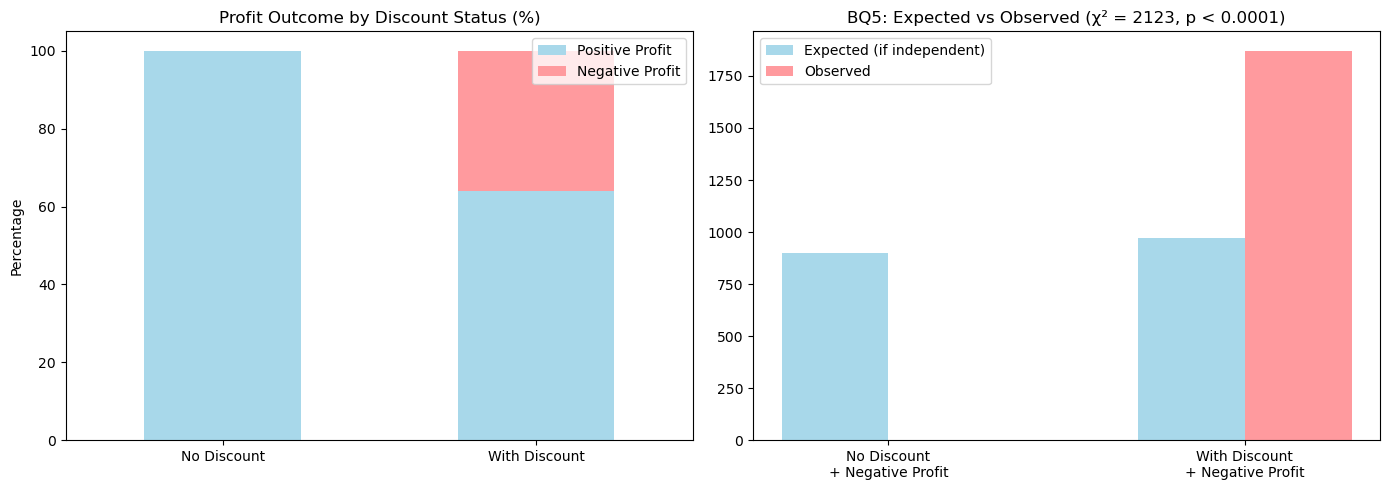

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
                                                 
# Left: stacked bar chart                                                              
ct = pd.crosstab(df["Has_Discount"], df["Negative_Profit"], normalize="index") * 100
ct.index = ["No Discount", "With Discount"]                                            
ct.columns = ["Positive Profit", "Negative Profit"]                                    
ct.plot(kind="bar", stacked=True, color=["#a8d8ea", "#ff9a9e"], ax=axes[0])
axes[0].set_title("Profit Outcome by Discount Status (%)")                             
axes[0].set_ylabel("Percentage")                                                       
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(loc="upper right")                                                      
                                                            
# Right: expected vs observed                                                          
labels = ["No Discount\n+ Negative Profit", "With Discount\n+ Negative Profit"]        
observed = [0, 1871]                                                           
expected_vals = [expected[0][1], expected[1][1]]                                       
x = range(len(labels))                                    
axes[1].bar([i - 0.15 for i in x], expected_vals, 0.3, label="Expected (if independent)", color="#a8d8ea")                                            
axes[1].bar([i + 0.15 for i in x], observed, 0.3, label="Observed", color="#ff9a9e")   
axes[1].set_xticks(x)                                                               
axes[1].set_xticklabels(labels)                                                        
axes[1].set_title(f"BQ5: Expected vs Observed (χ² = {chi2:.0f}, p < 0.0001)")
axes[1].legend()                                                                       
                                                                                         
plt.tight_layout()                                                                     
plt.savefig("../figures/bq5_discount_profit.png")                                      
plt.show() 

```
Wie du die Plots liest:                                                                
   
  Links (Stacked Bar):                                                                   
  - Jeder Balken = 100% der Transaktionen in dieser Gruppe  
  - Rosa = negativer Profit, Blau = positiver Profit                                     
  - Bei "No Discount" sollte 0% rosa sein — kein einziger Verlust ohne Rabatt!
  - Bei "With Discount" siehst du den Anteil der Verlust-Transaktionen                   
                                                                                         
  Rechts (Expected vs Observed):                                                         
  - Blau = was wir erwarten würden wenn Discount und Profit unabhängig wären             
  - Rosa = was tatsächlich passiert                                                      
  - Wenn die rosa Balken stark von den blauen abweichen → starker Zusammenhang
  - Besonders krass: "No Discount + Negative Profit" — erwartet wären ~900, beobachtet: 0
```

#### BQ5 Result (Climax)                                                               
                                                            
  | Metric | Value | Interpretation |                                                    
  |---|---|---|
  | Chi² statistic | 2123.26 | Extremely large (critical value at dof=1: 3.84) |         
  | Degrees of freedom | 1 | 2×2 contingency table |        
  | P-value | 0.0000 | Highly significant |                                              
                                                                                         
  **Result: H₀ rejected.** There is an overwhelming association between discounts and    
  negative profit. Every single one of the 1,871 loss-making transactions (18.7%) had a  
  discount applied. Zero non-discounted transactions resulted in a loss. This is the     
  strongest finding in the entire analysis — discounts don't just reduce profit, they are
   the sole driver of losses.

## Hypothesis Testing Summary                                                        
                                                                                         
  | BQ | Question | Test | P-value | Result |                                            
  |---|---|---|---|---|
  | BQ1 | GDP → Profit | Linear Regression | 0.6264 | H₀ not rejected |                  
  | BQ2 | Internet → Transactions | Pearson (one-tailed) | 0.3085 | H₀ not rejected |    
  | BQ3 | Discount by Region | t-Test | 0.0000 | H₀ rejected |                           
  | BQ4 | Profit by Segment | ANOVA (clipped) | 0.2087 | H₀ not rejected |               
  | BQ5 | Discount → Losses | Chi² | 0.0000 | H₀ rejected |                              
                                                                                         
  ### Key Takeaways                                                                      
  1. **External factors don't matter:** Neither GDP per capita nor internet penetration
  predict AWS SaaS performance (BQ1, BQ2)                                                
  2. **Discount strategy varies by region:** EMEA discounts significantly more than AMER
  (14.1% vs 10.9%), and APJ is the most aggressive (27%) (BQ3)                           
  3. **Segment doesn't drive profit:** Even after removing outliers, SMB, Strategic, and
  Enterprise show no significant profit difference (BQ4)                                 
  4. **Discounts are the sole driver of losses:** 100% of 1,871 loss-making transactions
  had a discount applied — zero exceptions (BQ5)                                         
                                                            
  > **The story:** It doesn't matter where the customer is from or what segment they     
  belong to. The single most important factor for AWS SaaS profitability is discount
  strategy. 